In [13]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont

In [14]:
# ==============================
# CONFIG
# ==============================
ENV_NAME = "Acrobot-v1"
NUM_BINS = 10
GAMMA = 0.99
MAX_STEPS = 500

ALPHAS = [0.05, 0.1, 0.2]
EPSILONS = [0.05, 0.1, 0.2]

TUNE_EPISODES = 500
FINAL_EPISODES = 25000
NUM_SEEDS = 10

In [15]:
# ==============================
# Discretization
# ==============================
def create_bins(env):
    low = env.observation_space.low
    high = env.observation_space.high
    return [
        np.linspace(low[i], high[i], NUM_BINS - 1)
        for i in range(len(low))
    ]

def discretize(obs, bins):
    return tuple(np.digitize(obs[i], bins[i]) for i in range(len(obs)))

In [16]:
# ==============================
# Policy
# ==============================
def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

In [17]:
# ==============================
# Training
# ==============================
def train(algo, alpha, epsilon, episodes, seed, decay=True):
    np.random.seed(seed)
    env = gym.make(ENV_NAME)
    env.reset(seed=seed)

    bins = create_bins(env)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))

    eps = epsilon
    eps_min = 0.01
    eps_decay = 0.995

    returns = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        state = discretize(obs, bins)
        action = epsilon_greedy(Q, state, eps, n_actions)

        total_reward = 0

        for _ in range(MAX_STEPS):
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize(next_obs, bins)

            if algo == "sarsa":
                next_action = epsilon_greedy(Q, next_state, eps, n_actions)
                target = reward + (0 if done else GAMMA * Q[next_state][next_action])
                Q[state][action] += alpha * (target - Q[state][action])
                state, action = next_state, next_action

            else:
                best_next = np.max(Q[next_state])
                target = reward + (0 if done else GAMMA * best_next)
                Q[state][action] += alpha * (target - Q[state][action])
                state = next_state
                action = epsilon_greedy(Q, state, eps, n_actions)

            total_reward += reward
            if done:
                break

        returns.append(total_reward)

        if decay:
            eps = max(eps_min, eps * eps_decay)

    env.close()
    return Q, np.array(returns)

In [18]:
# ==============================
# Hyperparameter tuning
# ==============================
def tune(algo):
    results = []
    for a in ALPHAS:
        for e in EPSILONS:
            _, r = train(algo, a, e, TUNE_EPISODES, seed=0)
            score = r[-100:].mean()
            results.append(((a, e), score))

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:3]

print("Tuning SARSA...")
top_sarsa = tune("sarsa")

print("Tuning Q-learning...")
top_q = tune("qlearn")

print("\nTop SARSA:", top_sarsa)
print("Top Q-learning:", top_q)

Tuning SARSA...
Tuning Q-learning...

Top SARSA: [((0.2, 0.05), np.float64(-383.72)), ((0.2, 0.1), np.float64(-405.2)), ((0.1, 0.2), np.float64(-414.54))]
Top Q-learning: [((0.2, 0.05), np.float64(-410.88)), ((0.1, 0.2), np.float64(-427.36)), ((0.1, 0.1), np.float64(-432.81))]


In [19]:
# ==============================
# Final evaluation
# ==============================
def evaluate(algo, alpha, epsilon):
    all_runs = []
    final_Q = None

    for seed in range(NUM_SEEDS):
        Q, r = train(algo, alpha, epsilon, FINAL_EPISODES, seed)
        all_runs.append(r)

        if seed == 0:
            final_Q = Q

    return final_Q, np.array(all_runs)

best_sarsa = top_sarsa[0][0]
best_q = top_q[0][0]

print("\nRunning final evaluation...")

sarsa_Q, sarsa_runs = evaluate("sarsa", *best_sarsa)
q_Q, q_runs = evaluate("qlearn", *best_q)


Running final evaluation...


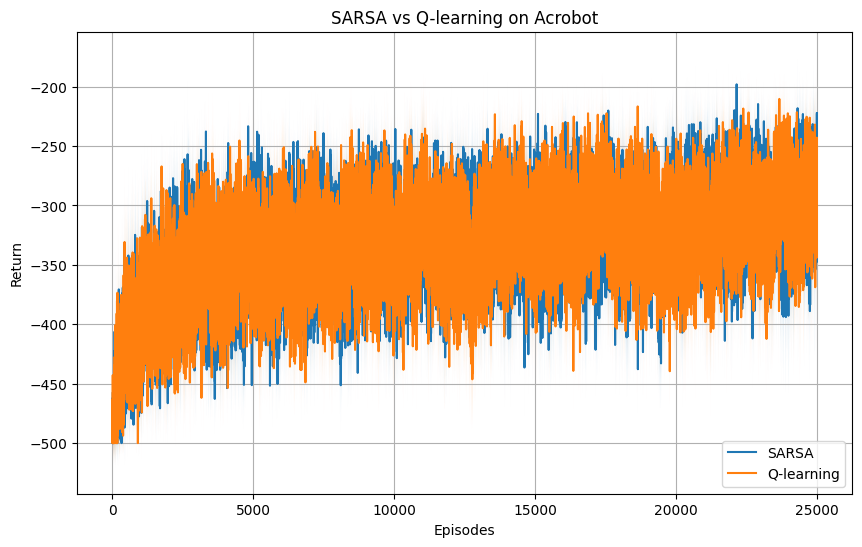

In [20]:
# ==============================
# Plot learning curves
# ==============================
def plot_with_ci(data, label):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])

    plt.plot(mean, label=label)
    plt.fill_between(
        np.arange(len(mean)),
        mean - ci,
        mean + ci,
        alpha=0.2
    )

plt.figure(figsize=(10,6))
plot_with_ci(sarsa_runs, "SARSA")
plot_with_ci(q_runs, "Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("SARSA vs Q-learning on Acrobot")
plt.legend()
plt.grid()
plt.show()

In [21]:
# ==============================
# GIF generation with text
# ==============================

def generate_gif(Q, algo_name, filename):

    env = gym.make(ENV_NAME, render_mode="rgb_array")
    bins = create_bins(env)

    frames = []

    obs, _ = env.reset(seed=0)
    state = discretize(obs, bins)

    try:
        font = ImageFont.truetype("arialbd.ttf", 200)
    except:
        font = ImageFont.load_default()

    for step in range(MAX_STEPS):

        frame = env.render()

        img = Image.fromarray(frame)
        draw = ImageDraw.Draw(img)

        text = f"{algo_name} | Step: {step}"

        # draw black rectangle behind text
        bbox = draw.textbbox((10,10), text, font=font)
        draw.rectangle(bbox, fill=(255,255,255))

        draw.text((10,10), text, fill=(0,0,0), font=font)

        frames.append(np.array(img))

        action = np.argmax(Q[state])
        obs, reward, terminated, truncated, _ = env.step(action)
        state = discretize(obs, bins)

        if terminated or truncated:

            frame = env.render()
            img = Image.fromarray(frame)
            draw = ImageDraw.Draw(img)

            text = f"{algo_name} | Goal reached in {step+1} steps"

            bbox = draw.textbbox((10,10), text, font=font)
            draw.rectangle(bbox, fill=(255,255,255))
            draw.text((10,10), text, fill=(0,0,0), font=font)

            frames.append(np.array(img))
            break

    env.close()

    imageio.mimsave(filename, frames, fps=60)

    print(f"Saved {filename}")


# ==============================
# Generate GIFs
# ==============================
generate_gif(sarsa_Q, "SARSA", "sarsa_acrobot.gif")
generate_gif(q_Q, "Q-learning", "qlearning_acrobot.gif")

Saved sarsa_acrobot.gif
Saved qlearning_acrobot.gif
